In [1]:
%%capture

%pip install lightning seaborn

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD

import lightning as L
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
training_inputs = torch.tensor([0.0, 0.5, 1.0])
training_labels = torch.tensor([0.0, 1.0, 0.0])

training_dataset = TensorDataset(training_inputs, training_labels)
dataloader = DataLoader(training_dataset)

In [4]:
class myNN(L.LightningModule):

    def __init__(self):

        super().__init__()

        self.w1 = nn.Parameter(torch.tensor(0.06))
        self.b1 = nn.Parameter(torch.tensor(0.0))

        self.w2 = nn.Parameter(torch.tensor(3.49))
        self.b2 = nn.Parameter(torch.tensor(0.0))

        self.w3 = nn.Parameter(torch.tensor(-4.11))
        self.w4 = nn.Parameter(torch.tensor(2.74))

        self.loss = nn.MSELoss(reduction='sum')


    def forward(self, input_values):

        top_x_axis_values = (input_values * self.w1) + self.b1
        bottom_x_axis_values = (input_values * self.w2) + self.b2

        top_y_axis_values = F.relu(top_x_axis_values)
        bottom_y_axis_values = F.relu(bottom_x_axis_values)

        output_values = (top_y_axis_values * self.w3) + (bottom_y_axis_values * self.w4)

        return output_values


    def configure_optimizers(self): # this configures the optimizer we want to use for backpropagation.
        return SGD(self.parameters(), lr=0.01)


    def training_step(self, batch, batch_idx): # take a step during gradient descent.
        inputs, labels = batch
        outputs = self.forward(inputs)
        loss = self.loss(outputs, labels)
        return loss

In [5]:
model = myNN() 
for name, param in model.named_parameters():
    print(name, torch.round(param.data, decimals=2))

w1 tensor(0.0600)
b1 tensor(0.)
w2 tensor(3.4900)
b2 tensor(0.)
w3 tensor(-4.1100)
w4 tensor(2.7400)


In [6]:
output_values = model(training_inputs)
torch.round(output_values, decimals=2)

tensor([0.0000, 4.6600, 9.3200], grad_fn=<RoundBackward1>)

In [9]:
input_doses = torch.linspace(start=0, end=1, steps=11)
input_doses

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])

In [10]:
output_values = model(input_doses)
output_values

tensor([0.0000, 0.9316, 1.8632, 2.7948, 3.7264, 4.6580, 5.5896, 6.5212, 7.4528,
        8.3844, 9.3160], grad_fn=<AddBackward0>)

Text(0.5, 0, 'Dose')

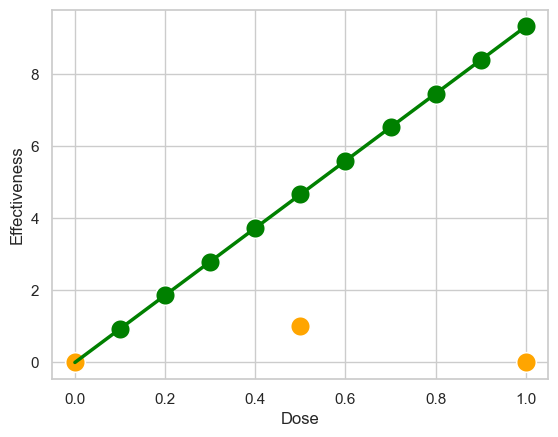

In [11]:
sns.set(style="whitegrid")

## First, draw the individual output points
sns.scatterplot(x=input_doses,
                y=output_values.detach().numpy(),
                color='green',
                s=200)

## Now connect those points with a line
sns.lineplot(x=input_doses,
             y=output_values.detach().numpy(), ## NOTE: We call .detatch() because...
             color='green',
             linewidth=2.5)

## Add the values in the training dataset
sns.scatterplot(x=training_inputs,
                y=training_labels,
                color='orange',
                s=200)

## now label the y- and x-axes.
plt.ylabel('Effectiveness')
plt.xlabel('Dose')

In [12]:
model = myNN()
## Now train the model...
trainer = L.Trainer(max_epochs=500, # how many times to go through the training data
                    logger=False,
                    enable_checkpointing=False,
                    enable_progress_bar=False)

trainer.fit(model, train_dataloaders=dataloader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type    | Params | Mode 
-------------------------------------------------
0 | loss         | MSELoss | 0      | train
  | other params | n/a     | 6      | n/a  
-------------------------------------------------
6         Trainable params
0         Non-trainable params
6         Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
/Users/aditagar/Desktop/statsquest/.venv/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=500` reached.


In [13]:
for name, param in model.named_parameters():
    print(name, torch.round(param.data, decimals=3))

w1 tensor(1.4790)
b1 tensor(-0.5680)
w2 tensor(2.6980)
b2 tensor(-0.2580)
w3 tensor(-4.2400)
w4 tensor(1.5830)


In [14]:
output_values = model(input_doses)
torch.round(output_values, decimals=2)

tensor([0.0000, 0.0200, 0.4500, 0.8700, 1.2000, 1.0000, 0.8000, 0.6000, 0.4000,
        0.2000, 0.0000], grad_fn=<RoundBackward1>)

Text(0.5, 0, 'Dose')

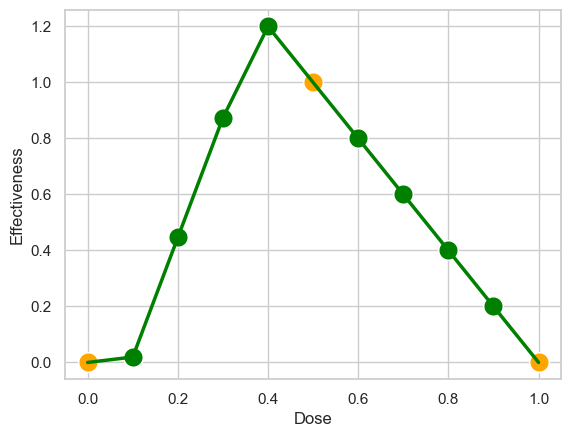

In [15]:
## First, set the style for seaborn so that the graph looks cool.
sns.set(style="whitegrid")

## First, draw the individual output points
sns.scatterplot(x=input_doses,
                y=output_values.detach().numpy(),
                color='green',
                s=200)

## Now connect those points with a line
sns.lineplot(x=input_doses,
             y=output_values.detach().numpy(), ## NOTE: We call .detatch() because...
             color='green',
             linewidth=2.5)

## Add the values in the training dataset
sns.scatterplot(x=training_inputs,
                y=training_labels,
                color='orange',
                s=200)

## now label the y- and x-axes.
plt.ylabel('Effectiveness')
plt.xlabel('Dose')